In [1]:
import torch
import torch.nn as nn

In [2]:
class Generator(nn.Module):
    
    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(
                100, 512, 4, 1, 0,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512, 256, 4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256, 128, 4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128, 64, 4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, 3, 4, 2, 1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [3]:
generator = Generator()

print(generator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding

In [4]:
noise = torch.randn(1,100,1,1)

print(noise.shape)

torch.Size([1, 100, 1, 1])


In [5]:
fake_image = generator(noise)

print(fake_image.shape)

torch.Size([1, 3, 64, 64])


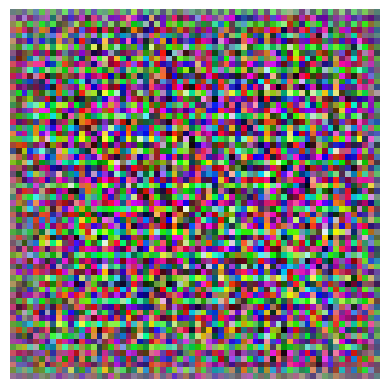

In [6]:
import matplotlib.pyplot as plt

image = fake_image.detach().squeeze(0)

image = image.permute(1,2,0)

image = (image + 1) / 2

plt.imshow(image)
plt.axis("off")
plt.show()